In [10]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 


In [11]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/precedence_distractor_test/").glob("*/*.pkl"))

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    diotic =  True if 'diotic' in path.stem else False 
    df['diotic'] = diotic
    df['diotic_cond'] = None
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    if diotic:
        target_loc = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')[0]
        df["target_azim"], df["target_elev"] = target_loc, target_loc
        distractor_loc = path.stem.split('_distract_loc_')[1].split('_')[0] 
        df["distractor_azim"], df["distractor_elev"] = distractor_loc, distractor_loc
        if snr == 'clean':
            df['diotic_cond'] = 'clean'
        else:
            df['diotic_cond'] = 'overlap' if target_loc == distractor_loc else distractor_loc
        df['dist_lead_channel'] = distractor_loc

    else:
        df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
        df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
        # map azim to 0-180
        df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
        df['target_elev'] = df['target_elev'].astype(int)
        df['distractor_elev'] = df['distractor_elev'].astype(int)
        lead_channel = path.stem.split('_lead_')[0].split('_')[-1]
        if lead_channel == 'None':
            if (df['target_azim'].values == df['distractor_azim'].values).all():
                lead_channel = 'F-F'
            elif (df['target_azim'].values != df['distractor_azim'].values).all():
                lead_channel = 'F-R'
        else:
            if lead_channel == 'center':
                lead_channel = 'F-FR'
            elif lead_channel == 'side':
                lead_channel = 'F-RF'
    
        df['dist_lead_channel'] = lead_channel

        
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    if 'clean' in path.stem:
        df['snr'] = 'clean'
    else:
        df['snr'] = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [12]:
results.loc[(results.distractor_azim != 0) & (results.dist_lead_channel == "F-F")] = results[results.dist_lead_channel == "F-F"] 

In [13]:
grouped_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim','dist_lead_channel',
                                 'distractor_elev', 'gender_cond', 'diotic', 'diotic_cond', 'snr']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# # grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
# grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
# grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
# grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

# grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
# grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

# grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
# grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [14]:
grouped_results.diotic_cond.unique()

array(['clean', 'overlap', 'left', 'right', 'center'], dtype=object)

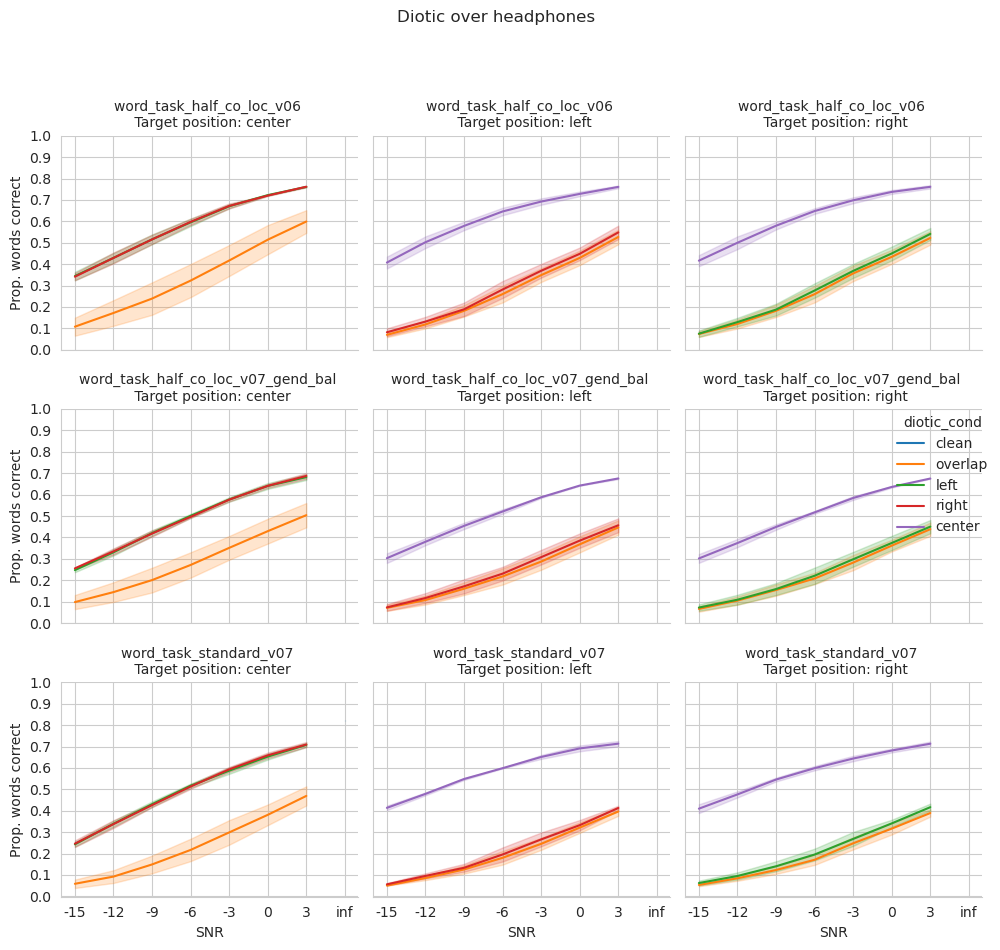

In [15]:
### Plot diotic precedense effect 


hue_order = ['clean', 'overlap', 'left', 'right', 'center']

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results[(grouped_results.diotic == True) ]#& (grouped_results.target_azim == 'center')]
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6


g = sns.relplot(data=to_plot,
                #palette=palette,
                x='snr', y='accuracy_mean', errorbar=('se', 1), markers="distractor_azim",
                hue='diotic_cond', kind='line', legend=True,
                row='model',
                palette=palette, col='target_azim',
                height=3)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim']==azim]
    # select the data for each hue group
    for group, selected in data.groupby('diotic_cond'):
        if group != 'clean':
            continue
        # plot the errorbar with the correct color for each group 
        print(group)
        ax.errorbar(data=selected, x="snr", y="accuracy_mean",
                     yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("SNR", "Prop. words correct")
g.set_titles("{row_name} \n Target position: {col_name}")
plt.suptitle("Diotic over headphones", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

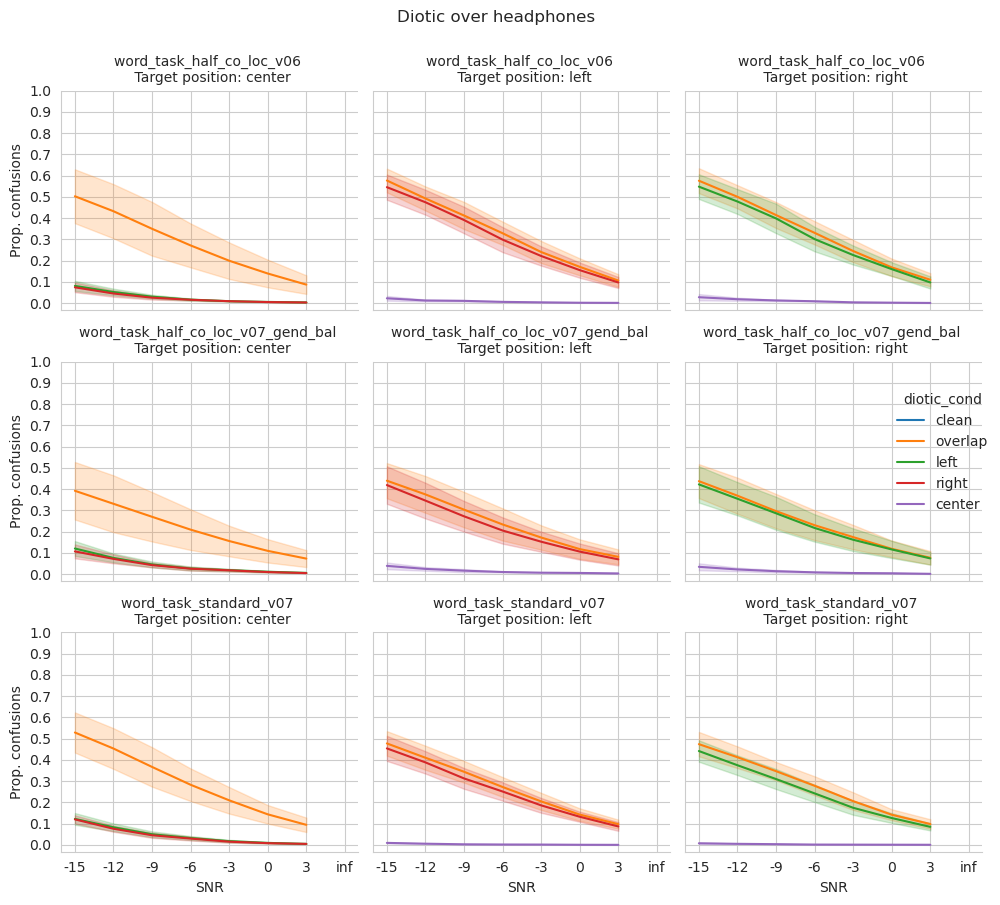

In [16]:
### Plot diotic precedense effect 


hue_order = ['clean', 'overlap', 'left', 'right', 'center']

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results[(grouped_results.diotic == True) ]#& (grouped_results.target_azim == 'center')]
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6


g = sns.relplot(data=to_plot,
                #palette=palette,
                x='snr', y='confusions_mean', errorbar=('se', 1), markers="distractor_azim",
                hue='diotic_cond', kind='line', legend=True,
                row='model',
                palette=palette, col='target_azim',
                height=3)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim']==azim]
    # select the data for each hue group
    for group, selected in data.groupby('diotic_cond'):
        if group != 'clean':
            continue
        # plot the errorbar with the correct color for each group 
        print(group)
        ax.errorbar(data=selected, x="snr", y="confusions_mean",
                     yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{row_name} \n Target position: {col_name}")
plt.suptitle("Diotic over headphones", y=1)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [17]:
freyman_grouped_results = results[results.diotic == False].groupby(['model', 'target_azim', 'distractor_azim', 'dist_lead_channel', 'gender_cond',  'snr']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
freyman_grouped_results.columns = ['_'.join(col).strip() for col in freyman_grouped_results.columns.values]
# remove trailing underscore
freyman_grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in freyman_grouped_results.columns.values]


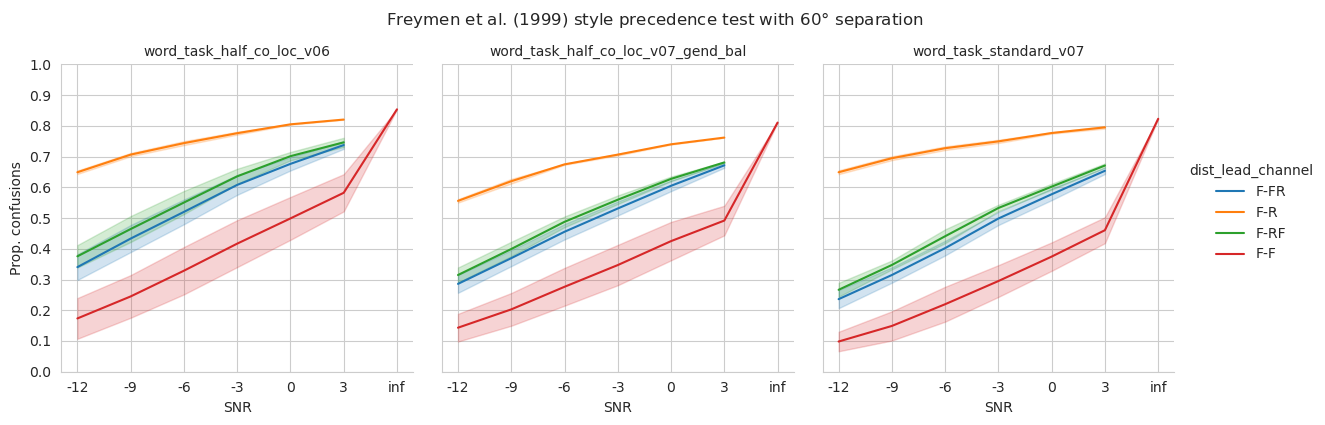

In [19]:

# palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = freyman_grouped_results.copy()
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
to_plot = to_plot[to_plot.snr > -15]

# copy 0 distractor condition to all other azims
to_plot.loc[to_plot.distractor_azim == 0, "distractor_azim"] = -60

# to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')] = to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')]

# copy 0 distractor condition to all other azims 
# to_plot.loc[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F'), 'distractor_azim'] = to_plot.loc[to_plot.distractor_azim == 0, 'target_azim']
g = sns.relplot(data=to_plot[to_plot.distractor_azim == -60],
                #palette=palette,
                x='snr', y='accuracy_mean', errorbar=('se', 1), 
                hue='dist_lead_channel', kind='line', legend=True,
            #    col='distractor_azim',
               col='model',
                #  palette=palette,
                height=4)
# # iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
#         # print(selected)
#         ax.errorbar(data=selected, x="distractor_azim", y="accuracy_mean",
#                      yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. accuracy")
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{col_name}")

plt.suptitle("Freymen et al. (1999) style precedence test with 60$\degree$ separation", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='accuracy_mean', hue='gender_cond', kind='line', col='target_azim')

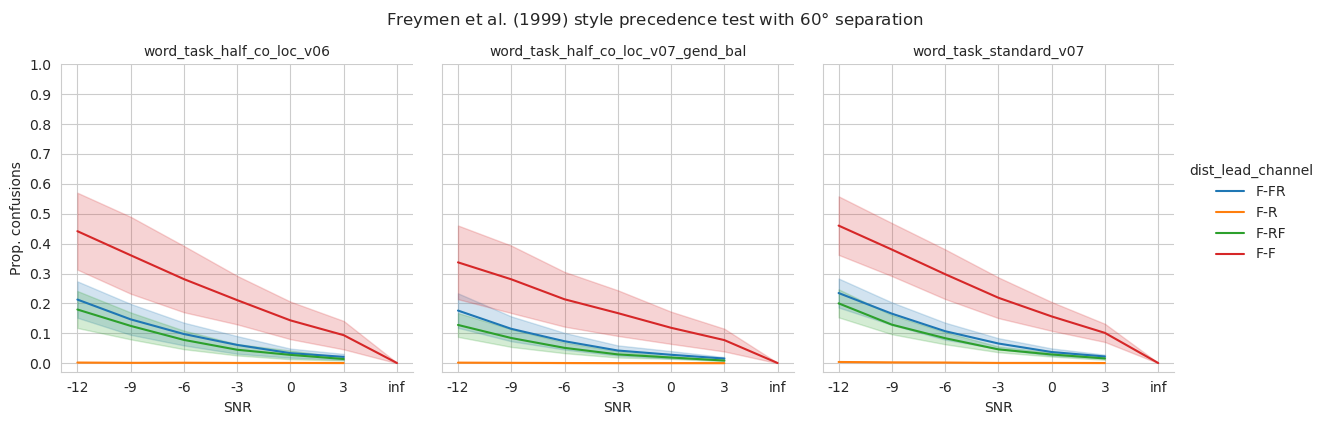

In [20]:

# palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = freyman_grouped_results.copy()
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
to_plot = to_plot[to_plot.snr > -15]
# copy 0 distractor condition to all other azims
to_plot.loc[to_plot.distractor_azim == 0, "distractor_azim"] = -60

# to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')] = to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')]

# copy 0 distractor condition to all other azims 
# to_plot.loc[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F'), 'distractor_azim'] = to_plot.loc[to_plot.distractor_azim == 0, 'target_azim']
g = sns.relplot(data=to_plot[to_plot.distractor_azim == -60],
                #palette=palette,
                x='snr', y='confusions_mean', errorbar=('se', 1), 
                hue='dist_lead_channel', kind='line', legend=True,
            #    col='distractor_azim',
               col='model',
                #  palette=palette,
                height=4)
# # iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
#         # print(selected)
#         ax.errorbar(data=selected, x="distractor_azim", y="confusions_mean",
#                      yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. accuracy")
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{col_name}")

plt.suptitle("Freymen et al. (1999) style precedence test with 60$\degree$ separation", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [ ]:
to_plot.groupby(['model', 'dist_lead_channel']).confusions_mean.mean()

model                               dist_lead_channel
word_task_half_co_loc_v06           F-F                  0.180925
                                    F-FR                 0.139587
                                    F-R                  0.012222
                                    F-RF                 0.117950
word_task_half_co_loc_v07_gend_bal  F-F                  0.199620
                                    F-FR                 0.115506
                                    F-R                  0.009755
                                    F-RF                 0.092318
word_task_standard_v07              F-F                  0.269011
                                    F-FR                 0.139485
                                    F-R                  0.008476
                                    F-RF                 0.113027
Name: confusions_mean, dtype: float64

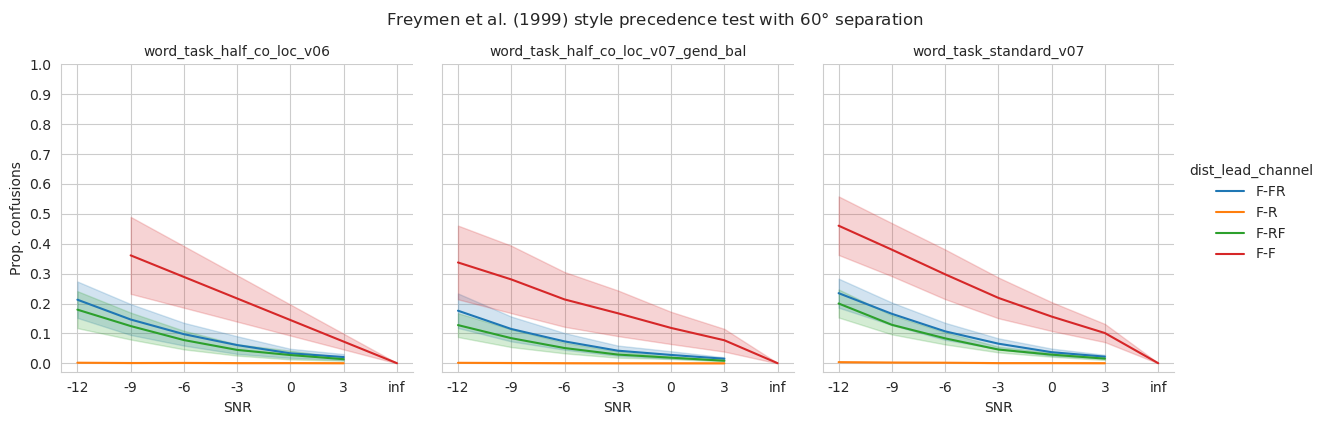

In [ ]:

# palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = freyman_grouped_results[freyman_grouped_results.snr > -15]
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
# copy 0 distractor condition to all other azims
to_plot.loc[to_plot.distractor_azim == 0, "distractor_azim"] = -60

# to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')] = to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')]

# copy 0 distractor condition to all other azims 
# to_plot.loc[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F'), 'distractor_azim'] = to_plot.loc[to_plot.distractor_azim == 0, 'target_azim']
g = sns.relplot(data=to_plot[to_plot.distractor_azim == -60],
                #palette=palette,
                x='snr', y='confusions_mean', errorbar=('se', 1), 
                hue='dist_lead_channel', kind='line', legend=True,
            #    col='distractor_azim',
               col='model',
                #  palette=palette,
                height=4)
# # iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
#         # print(selected)
#         ax.errorbar(data=selected, x="distractor_azim", y="confusions_mean",
#                      yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. accuracy")
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{col_name}")

plt.suptitle("Freymen et al. (1999) style precedence test with 60$\degree$ separation", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

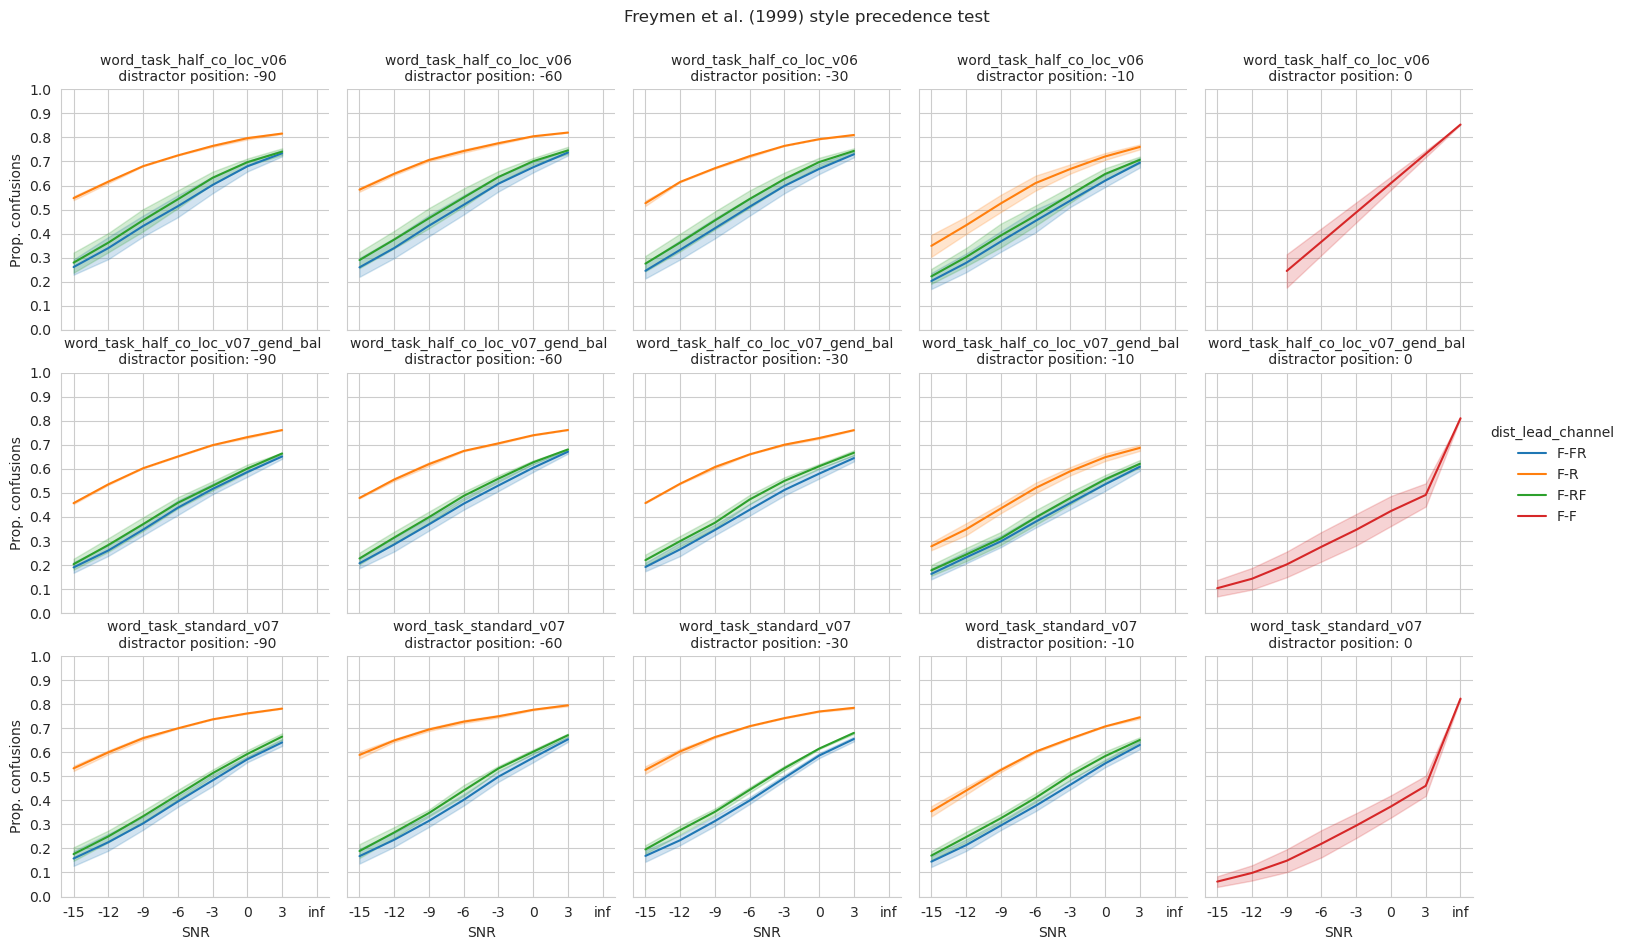

In [ ]:

# palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = freyman_grouped_results
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
# copy 0 distractor condition to all other azims

# to_plot[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F')] = to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')]

# copy 0 distractor condition to all other azims 
# to_plot.loc[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F'), 'distractor_azim'] = to_plot.loc[to_plot.distractor_azim == 0, 'target_azim']
g = sns.relplot(data=to_plot,
                #palette=palette,
                x='snr', y='accuracy_mean', errorbar=('se', 1), 
                hue='dist_lead_channel', kind='line', legend=True,
               col='distractor_azim',
               row='model',
                #  palette=palette,
                height=3)
# # iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
#         # print(selected)
#         ax.errorbar(data=selected, x="distractor_azim", y="accuracy_mean",
#                      yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. accuracy")
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{row_name} \n distractor position: {col_name}")
plt.suptitle("Freymen et al. (1999) style precedence test", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='accuracy_mean', hue='gender_cond', kind='line', col='target_azim')